In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
## simulation parameters
# distance
d_list = range(3,9,2)
# number of rounds
r_list = range(1,11)
# number of same jobs
job_number = 100

# Load json data

In [3]:
# fraction of accepted shots
Acceptance = np.zeros((len(d_list),len(r_list)))
# fraction of accepted shots uncertainty
Acceptance_u = np.zeros((len(d_list),len(r_list)))
# fraction of failed shots
Error = np.zeros((len(d_list),len(r_list)))
# fraction of failed shots uncertainty
Error_u = np.zeros((len(d_list),len(r_list)))

for index_d, d in enumerate(d_list):
    for index_r, r in enumerate(r_list):
        nb_accepted = 0
        nb_fail = 0
        batch_size = 0
        
        for index in range(job_number):
            result = json.load(open(f'./Results/result_{d}_{r}_{index}.json', 'r'))

            batch_size += result['batch_size']
            nb_fail += result['accepted&fail']
            nb_accepted += result['accepted']
                                       
        Acceptance[index_d,index_r] = nb_accepted/batch_size
        Acceptance_u[index_d,index_r] = np.sqrt(nb_accepted/batch_size*(1-nb_accepted/batch_size)/batch_size)
        
        if nb_accepted != 0:
            Error[index_d,index_r] = nb_fail/nb_accepted
            Error_u[index_d,index_r] = np.sqrt(nb_fail/nb_accepted*(1-nb_fail/nb_accepted)/nb_accepted)
        else:
            Error[index_d,index_r] = np.nan
            Error_u[index_d,index_r] = np.nan

# Acceptance

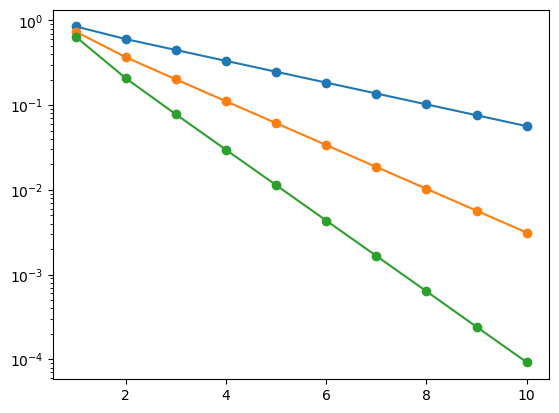

In [4]:
for index_d, d in enumerate(d_list):
    plt.plot(r_list,Acceptance[index_d],'-o')
    plt.fill_between(r_list,Acceptance[index_d] - 1.96*Acceptance_u[index_d],Acceptance[index_d] + 1.96*Acceptance_u[index_d],alpha = 0.25)
        
plt.yscale('log')

In [5]:
np.set_printoptions(linewidth=np.inf)
Acceptance

array([[8.48825232e-01, 6.02447542e-01, 4.47599806e-01, 3.33083459e-01, 2.47859446e-01, 1.84462286e-01, 1.37275550e-01, 1.02149467e-01, 7.60183950e-02, 5.65575330e-02],
       [7.38176982e-01, 3.67607411e-01, 2.01444750e-01, 1.11093668e-01, 6.12775200e-02, 3.38068990e-02, 1.86399370e-02, 1.02913600e-02, 5.67642200e-03, 3.13033900e-03],
       [6.41981843e-01, 2.07276025e-01, 7.78059190e-02, 2.96959700e-02, 1.13559710e-02, 4.33989900e-03, 1.65929700e-03, 6.34246000e-04, 2.41462000e-04, 9.23310000e-05]])

In [6]:
print("mean number of rounds")
print(6/Acceptance[2][5])

mean number of rounds
1382.5206531304068


# Logical Error

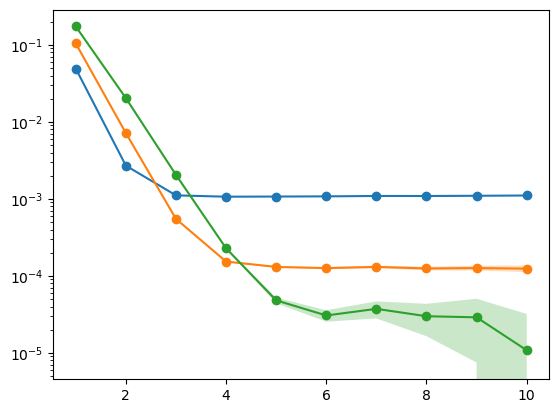

In [7]:
for index_d, d in enumerate(d_list):
    plt.plot(r_list,Error[index_d],'-o')
    plt.fill_between(r_list,Error[index_d] - 1.96*Error_u[index_d],Error[index_d] + 1.96*Error_u[index_d],alpha = 0.25)
        
plt.yscale('log')

In [8]:
Error

array([[4.92442972e-02, 2.70193152e-03, 1.11188609e-03, 1.06890027e-03, 1.07371337e-03, 1.07970580e-03, 1.09255436e-03, 1.09104828e-03, 1.09862883e-03, 1.10807521e-03],
       [1.04390762e-01, 7.15959723e-03, 5.49743788e-04, 1.53591112e-04, 1.30912609e-04, 1.26276001e-04, 1.31009026e-04, 1.24959189e-04, 1.26488129e-04, 1.24267691e-04],
       [1.73578624e-01, 2.03525565e-02, 2.05071802e-03, 2.28280134e-04, 4.81684922e-05, 3.06458745e-05, 3.73652215e-05, 2.99568306e-05, 2.89900688e-05, 1.08305986e-05]])